# Problem 2.6: Audio Downsampling (Decimation) and Aliasing

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
This problem uses the sound file `handel` available in MATLAB. This sound is sampled at $F_s = 8192$ samples per second using 8-bits per sample.
* **(a)** Load the `handel` sound and listen to it at the full sampling rate ($F_s = 8192$ Hz).
* **(b)** Downsample by a factor of 2: select every other sample ($x[2n]$), set $F_s = 4096$ Hz, and listen to the result.
* **(c)** Downsample by a factor of 4: select every fourth sample ($x[4n]$), set $F_s = 2048$ Hz, listen to the sound, and save the downsampled file.

In [ ]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display


ModuleNotFoundError: No module named 'IPython'

## (a) Load and Listen to Original Audio ($F_s = 8192$ Hz)
We read the audio file `handel.wav` and inspect its sampling rate and length.

In [ ]:
wav_path = Path('handel.wav')
x, Fs = sf.read(wav_path)

print(f"Original sampling rate: {Fs} Hz")
print(f"Number of samples: {len(x)}")
print(f"Duration: {len(x) / Fs:.2f} seconds")

# In-notebook audio player
display(Audio(data=x, rate=int(Fs)))


NameError: name 'display' is not defined

## (b) Downsample by a Factor of 2 ($F_s = 4096$ Hz)
Select every second sample: $x_{half}[n] = x[2n]$, reducing the sampling rate to $F_{s, half} = F_s / 2 = 4096$ Hz.

In [ ]:
x_half = x[::2]
Fs_half = Fs / 2

print(f"Downsampled by 2: Fs = {Fs_half} Hz, samples = {len(x_half)}")
display(Audio(data=x_half, rate=int(Fs_half)))


NameError: name 'display' is not defined

## (c) Downsample by a Factor of 4 ($F_s = 2048$ Hz) & Export
Select every fourth sample: $x_{quarter}[n] = x[4n]$, with $F_{s, quarter} = F_s / 4 = 2048$ Hz.
The result is saved to `handel_quarter.wav`.

In [ ]:
x_quarter = x[::4]
Fs_quarter = Fs / 4

print(f"Downsampled by 4: Fs = {Fs_quarter} Hz, samples = {len(x_quarter)}")
display(Audio(data=x_quarter, rate=int(Fs_quarter)))

# Save the downsampled sound file
output_path = Path('handel_quarter.wav')
sf.write(output_path, x_quarter, int(Fs_quarter))
print(f"Saved to {output_path}")


NameError: name 'display' is not defined

## Waveform Comparison
Plot the waveforms of the original and downsampled signals versus discrete time index $n$.

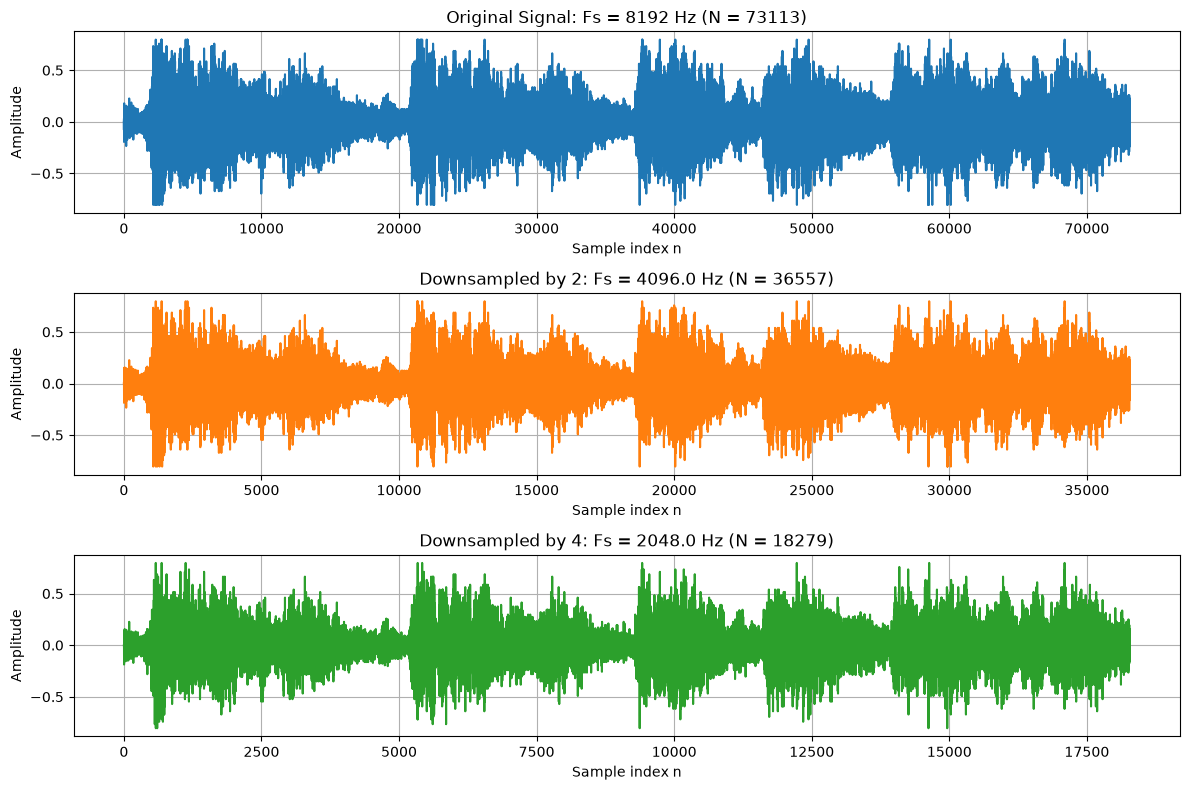

In [10]:
n = np.arange(len(x))
n_half = np.arange(len(x_half))
n_quarter = np.arange(len(x_quarter))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(n, x, color='tab:blue')
plt.title(f'Original Signal: Fs = {Fs} Hz (N = {len(x)})')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(n_half, x_half, color='tab:orange')
plt.title(f'Downsampled by 2: Fs = {Fs_half} Hz (N = {len(x_half)})')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(n_quarter, x_quarter, color='tab:green')
plt.title(f'Downsampled by 4: Fs = {Fs_quarter} Hz (N = {len(x_quarter)})')
plt.xlabel('Sample index n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


### Q&A
- **Question:** What happens to the audio quality when downsampling by factors of 2 and 4 without pre-filtering?
- **Answer:** As the sampling frequency decreases from $8192$ Hz to $4096$ Hz and $2048$ Hz, the sound becomes increasingly muffled and metallic/scratchy due to loss of high frequencies and aliasing distortion.

### Data Analysis Key Findings
- **Bandwidth Reduction:** According to the Nyquist theorem, the maximum reproducible frequency (Nyquist limit) drops from $F_{max} = 4096$ Hz (original) down to $2048$ Hz (downsampled by 2) and $1024$ Hz (downsampled by 4).
- **Aliasing Artifacts:** Frequency components present in the original signal above the new Nyquist limit ($F_s / 2$) fold back into the audible baseband, creating unnatural spectral distortion.

### Insights or Next Steps
- **Anti-aliasing Filter (Decimation):** In proper DSP practice, downsampling should always be preceded by an anti-aliasing low-pass filter (decimation filter) with cutoff at $\omega_c = \pi / D$ to remove frequencies above the new Nyquist rate before discarding samples (`scipy.signal.decimate`).